# BC-515: SIGMA original workflow

Library implementation

This notebook follows the original BC-515 analysis: a Gaussian spatial prior and spectral residual network produce a region field and signed interface distance. Robust exponential decay fits then identify boundary-associated MSI features. Signed-distance profiles of the first 300 retained features define four metabolic programs.

The data contain 3,508 spots and 2,086 MSI features. This run uses all spots, 1,000 training epochs, seed 0 and one CPU thread. Saved outputs below come from executing these cells. The original notebook's saved numbers are shown separately, because matching a protocol does not guarantee identical results across software and hardware environments.

MSI intensities come from `uns['msi']`; `X` is RNA expression. Distance and lambda are in the input spatial coordinate units. No conversion to micrometres is assumed.

## Environment and parameters

In [1]:
from pathlib import Path
import os, sys, json, hashlib, platform, time, importlib.metadata

# Resolve the tutorial folder from the current directory or its parents.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "01_METMAP_library.ipynb").is_file() and (p / "vendor").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Open Jupyter from the METMAP-SIGMA-Tutorials folder or one of its subdirectories.")
HERE = ROOT
INPUT = Path(os.environ.get("BC515_DATA", HERE / "data/BC_515_Section_1.h5ad")).expanduser().resolve()
if not INPUT.is_file():
    raise FileNotFoundError("Place BC_515_Section_1.h5ad in data/ or set BC515_DATA. See DATA.md.")
os.environ.update(OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1", MKL_NUM_THREADS="1")
os.environ.setdefault("MPLCONFIGDIR", str(HERE / ".mplconfig"))
try:
    import random
    import numpy as np
    import pandas as pd
    import scipy
    from scipy.sparse import issparse
    import sklearn
    import anndata as ad
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch_geometric
    from torch_geometric.data import Data
    from torch_geometric.nn import MessagePassing
    from torch_geometric.utils import add_self_loops, degree
    from sklearn.decomposition import TruncatedSVD
    from sklearn.preprocessing import RobustScaler
    from sklearn.neighbors import NearestNeighbors
    from threadpoolctl import threadpool_limits
    import matplotlib.pyplot as plt
    from sklearn.linear_model import HuberRegressor
    from sklearn.metrics import r2_score
    from sklearn.cluster import AgglomerativeClustering
    from IPython.display import display
except ModuleNotFoundError as exc:
    raise RuntimeError("Missing dependency: install the environment described in README and select its Jupyter kernel.") from exc

torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass  # Allow the setup cell to run again in the same kernel.
THREAD_LIMITER = threadpool_limits(limits=1)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "image.cmap": "viridis"})
SEED = 0
CORE = dict(n_components=64, k=15, z_dim=32, epochs=1000, lr=1e-3,
            lambda_sup=0.05, beta_rna=0.05, boundary_k=10)
INPUT = Path(os.environ.get("BC515_DATA", HERE / "data/BC_515_Section_1.h5ad")).expanduser().resolve()

def sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

versions = {"python": platform.python_version(), "numpy": np.__version__,
            "scipy": scipy.__version__, "scikit-learn": sklearn.__version__,
            "torch": torch.__version__, "torch-geometric": torch_geometric.__version__,
            "anndata": ad.__version__}
display(pd.Series(versions, name="Runtime version").to_frame())
print("Python:", platform.python_version())
print("Protocol:", CORE, "seed=0, device=cpu, threads=1, boundary_mode=legacy")
PROTOCOL = "BC515-original-2026-09"
RANKING = dict(var_top=2000, min_valid=300, min_r2=0.05, min_enrichment=1.05, lambda_upper_quantile=0.99)

<environment>/lib/python3.11/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/var/folders/ly/l_ycn3sd0jg23c12y2s283180000gn/T/ipykernel_41957/3126494946.py:66: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  "anndata": ad.__version__}


,Runtime version
python,3.11.13
numpy,1.26.4
scipy,1.16.0
scikit-learn,1.7.1
torch,2.2.2
torch-geometric,2.5.3
anndata,0.12.19


Python: 3.11.13
Protocol: {'n_components': 64, 'k': 15, 'z_dim': 32, 'epochs': 1000, 'lr': 0.001, 'lambda_sup': 0.05, 'beta_rna': 0.05, 'boundary_k': 10} seed=0, device=cpu, threads=1, boundary_mode=legacy


In [2]:
IMPLEMENTATION = 'library'
OUT = HERE / "results/sigma_library"
OUT.mkdir(parents=True, exist_ok=True)

## Data and weak supervision

`uns['msi']` stores the measured MSI intensities. `X` stores RNA gene expression.
The first 32 dimensions of the precomputed `X_harmony` representation provide the auxiliary RNA reconstruction target. Upstream Harmony processing is not repeated.
Tumor and Stroma spots are positive and negative anchors. The 77 Unlabelled spots are excluded from the supervised loss but retained in the spatial graph, MSI/RNA reconstruction, and outputs.
Because the annotations are used for training, agreement with them does not provide independent validation.

,Input,Location,Shape / count
0,MSI intensities,uns['msi'],"(3508, 2086)"
1,Auxiliary RNA representation,"obsm['X_harmony'][:, :32]","(3508, 32)"
2,Spatial coordinates,obsm['spatial'],"(3508, 2)"
3,Weak annotations,obs['annotation'],3508
4,RNA gene expression (not MSI),X,"(3508, 15953)"


,spots
annotation,
Stroma,2707
Tumor,724
Unlabelled,77


Input SHA256: 1f96d6f1aaa36c117ccd7fb94b172a1c1435585d54279e8cffb93df0299c7204
MSI storage: ndarray | all 3,508 spots and 2,086 m/z features retained


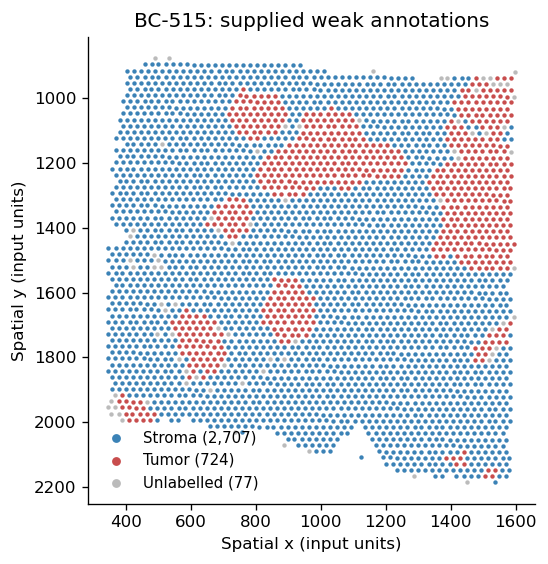

In [3]:
# Load the original data for training.
adata = ad.read_h5ad(INPUT)
assert adata.n_obs == 3508 and adata.uns["msi"].shape == (3508, 2086)
assert adata.obsm["X_harmony"].shape[0] == adata.n_obs
assert adata.obs_names.is_unique
xy = np.asarray(adata.obsm["spatial"], dtype=np.float32)
annotation = adata.obs["annotation"].astype(str).to_numpy()
msi = adata.uns["msi"]
values = msi.data if issparse(msi) else np.asarray(msi)
assert np.isfinite(values).all() and np.min(values) >= 0
input_hash = sha256(INPUT)
display(pd.DataFrame({
    "Input": ["MSI intensities", "Auxiliary RNA representation", "Spatial coordinates", "Weak annotations", "RNA gene expression (not MSI)"],
    "Location": ["uns['msi']", "obsm['X_harmony'][:, :32]", "obsm['spatial']", "obs['annotation']", "X"],
    "Shape / count": [str(msi.shape), str(adata.obsm['X_harmony'][:, :32].shape), str(xy.shape),
             str(adata.n_obs), str(adata.shape)]}))
display(adata.obs["annotation"].value_counts().rename("spots").to_frame())
print("Input SHA256:", input_hash)
print("MSI storage:", type(msi).__name__, "| all 3,508 spots and 2,086 m/z features retained")

fig, ax = plt.subplots(figsize=(5.4, 4.8))
for label, color in [("Stroma", "#3B82B6"), ("Tumor", "#C84D4D"), ("Unlabelled", "#BBBBBB")]:
    use = annotation == label
    ax.scatter(xy[use, 0], xy[use, 1], s=7, c=color, label=f"{label} ({use.sum():,})", linewidths=0)
ax.set(title="BC-515: supplied weak annotations", xlabel="Spatial x (input units)", ylabel="Spatial y (input units)")
ax.set_aspect("equal"); ax.invert_yaxis(); ax.legend(frameon=False, markerscale=2, fontsize=9)
fig.tight_layout(); plt.show()
mz_names = np.asarray(adata.uns["mz_features"]).astype(str)
X_msi = msi

## Train the original SIGMA core

The bundled source is **SIGMA 0.3.1+bc515.original**, a documented compatibility revision of 0.3.1. It restores the original RNA-first head initialization, diffusion arithmetic, class-weight dtype, NumPy sigmoid, raw-intensity profile aggregation and module scoring. See `vendor/SIGMA/ORIGINAL_COMPATIBILITY.md`. It is not an unchanged PyPI release.

In [4]:
SOURCE = ROOT / "vendor/SIGMA/src"
sys.path.insert(0, str(SOURCE))
import sigma_spatial as sigma
assert sigma.__version__ == "0.3.1+bc515.original", "Restart the kernel to load the original-protocol source."
assert Path(sigma.__file__).resolve().is_relative_to(SOURCE.resolve())
print("Imported SIGMA:", sigma.__version__)
estimator = sigma.SIGMA(n_components=CORE["n_components"], k=CORE["k"], seed=SEED, device="cpu")
start = time.perf_counter()
print("Training the original BC-515 protocol for 1,000 epochs.", flush=True)
estimator.fit(adata, annotation_key="annotation", tumor_label="Tumor", stroma_label="Stroma",
              rna_key="X_harmony", z_dim=CORE["z_dim"], epochs=CORE["epochs"], lr=CORE["lr"],
              lambda_sup=CORE["lambda_sup"], beta_rna=CORE["beta_rna"],
              boundary_k=CORE["boundary_k"], boundary_mode="legacy")
training_seconds = time.perf_counter() - start
loss_history = estimator.loss_history_
model = estimator.model_
embedding = np.asarray(adata.obsm["X_sigma_msi"])
gaussian = np.asarray(adata.obsm["X_sigma_gauss"])
residual = np.asarray(adata.obsm["X_sigma_residual"])
gaussian_anchor = adata.obs["sigma_gaussian_anchor"].to_numpy()
xy = np.asarray(adata.obsm["spatial"], dtype=float)
print(f"Training completed in {training_seconds:.1f} seconds.")

Imported SIGMA: 0.3.1+bc515.original
Training the original BC-515 protocol for 1,000 epochs.


Training completed in 133.9 seconds.


## Region field, boundary and signed distance

The normalized region score is a within-section visualization and boundary-construction score; it is not a calibrated probability. Weak annotations were used during training.

,Fresh result
spots,3508.000000
MSI features,2086.000000
epochs,1000.000000
initial training loss,0.425294
final training loss,0.155556
inside spots,751.000000
boundary spots,838.000000
training seconds,133.910669


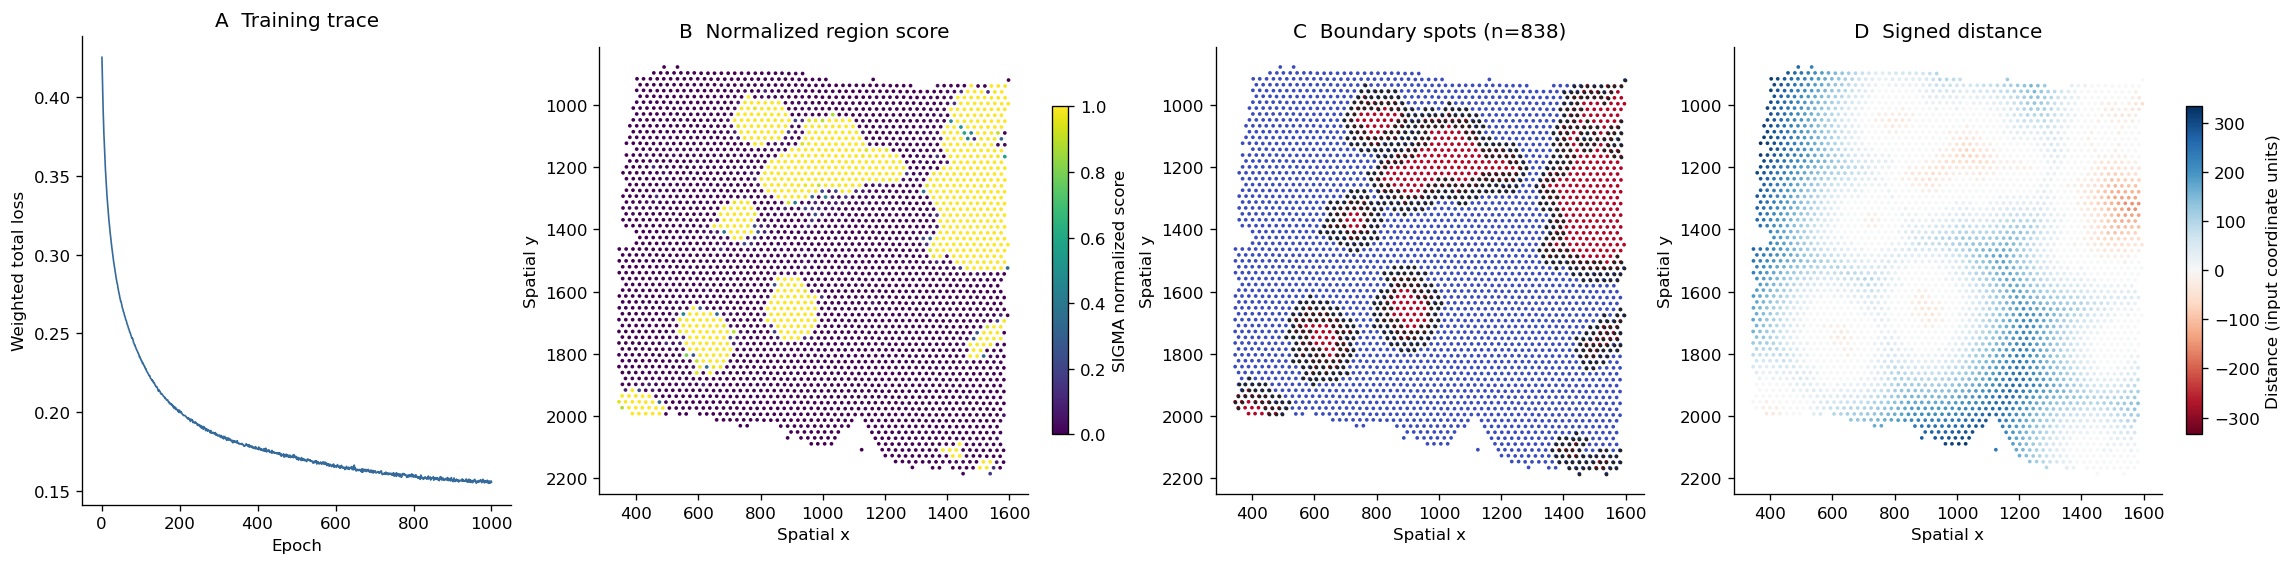

In [5]:
probability = adata.obs["sigma_region_probability"].to_numpy()
p_raw = adata.obs["sigma_region_probability_raw"].to_numpy()
boundary = adata.obs["sigma_boundary"].to_numpy(bool)
inside = adata.obs["sigma_inside"].to_numpy(bool)
d_signed = adata.obs["sigma_d_signed"].to_numpy()
assert np.isfinite(probability).all() and np.isfinite(d_signed).all()
assert boundary.any() and inside.any() and (~inside).any()
assert len(loss_history) == CORE["epochs"]
display(pd.Series({"spots": adata.n_obs, "MSI features": msi.shape[1],
                   "epochs": len(loss_history), "initial training loss": loss_history[0],
                   "final training loss": loss_history[-1], "inside spots": int(inside.sum()),
                   "boundary spots": int(boundary.sum()), "training seconds": training_seconds},
                  name="Fresh result").to_frame())

fig, axes = plt.subplots(1, 4, figsize=(19, 4.6), layout="constrained")
axes[0].plot(np.arange(1, len(loss_history)+1), loss_history, color="#356B9C", lw=1)
axes[0].set(title="A  Training trace", xlabel="Epoch", ylabel="Weighted total loss")
image = axes[1].scatter(xy[:, 0], xy[:, 1], c=probability, s=5, vmin=0, vmax=1, linewidths=0)
axes[1].set_title("B  Normalized region score")
fig.colorbar(image, ax=axes[1], shrink=.7, label="SIGMA normalized score")
axes[2].scatter(xy[:, 0], xy[:, 1], c=inside, cmap="coolwarm", s=5, linewidths=0)
axes[2].scatter(xy[boundary, 0], xy[boundary, 1], c="#222222", s=5, linewidths=0)
axes[2].set_title(f"C  Boundary spots (n={boundary.sum():,})")
limit = np.max(np.abs(d_signed))
image = axes[3].scatter(xy[:, 0], xy[:, 1], c=d_signed, cmap="RdBu", s=5,
                        vmin=-limit, vmax=limit, linewidths=0)
axes[3].set_title("D  Signed distance")
fig.colorbar(image, ax=axes[3], shrink=.7, label="Distance (input coordinate units)")
for ax in axes[1:]:
    ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set(xlabel="Spatial x", ylabel="Spatial y")
fig.savefig(OUT / "core_results.png", bbox_inches="tight")
fig.savefig(OUT / "core_results.pdf", bbox_inches="tight")
plt.show()

## Boundary-associated decay features

For each of the 2,000 most variable MSI features, fit

`log1p(I - min(I)) = intercept + slope × abs(d_signed)`

with Huber regression. A negative slope gives `lambda = -1 / slope`. Retain features with at least 300 valid spots, R² ≥ 0.05 and near/far mean intensity ratio ≥ 1.05. Near and far use the 20th and 80th absolute-distance percentiles. Remove the upper 1% of retained lambda values, then rank by R² and enrichment. This is the original distance-decay ranking.

In [6]:
ranking = sigma.rank_lambda_profiles(
    adata, matrix_source="msi_uns", distance_key="sigma_d_signed",
    var_top=2000, min_valid=300, near_quantile=0.20, far_quantile=0.80,
    min_r2=0.05, min_enrichment=1.05, lambda_upper_quantile=0.99,
    already_log=False, ranking_col="r2_logI")

In [7]:
assert not ranking.empty, "No features passed the original distance-decay filters."
assert (ranking["slope"] < 0).all()
assert (ranking["r2_logI"] >= 0.05).all()
assert (ranking["boundary_enrichment_ratio"] >= 1.05).all()
print(f"Retained {len(ranking)} boundary-decay features from 2,000 variance-selected candidates.")
display(ranking[["mz", "j", "lambda", "r2_logI", "boundary_enrichment_ratio"]].head(10))
ranking.to_csv(OUT / "lambda_ranking.csv", index=False)

Retained 312 boundary-decay features from 2,000 variance-selected candidates.


,mz,j,lambda,r2_logI,boundary_enrichment_ratio
0,817.534520,320,226.598438,0.270282,2.411772
1,818.540767,134,195.740959,0.269265,2.569555
2,887.561462,75,173.717959,0.268716,3.657773
3,816.535523,127,235.808809,0.265604,2.229208
4,819.539764,267,190.766553,0.256956,2.912609
5,768.537265,91,209.982640,0.251133,2.620186
6,766.534921,60,198.043845,0.251068,2.701397
7,822.568654,158,195.255653,0.249306,2.805875
8,820.559060,74,185.205432,0.245908,2.800793
9,885.548969,25,196.482274,0.242049,2.472738


## Directional variation of influence range

Eight angular sectors are defined around the tissue center. Anisotropy is the population standard deviation of valid sector lambda values divided by their mean, with at least three valid sectors.

In [8]:
def column_get(X, j):
    """
    Extract the j-th feature vector from dense or sparse matrix.

    Parameters
    ----------
    X : array-like or sparse matrix
        MSI feature matrix.
    j : int
        Feature index.

    Returns
    -------
    y : ndarray, shape (n_spots,)
        Feature intensity vector.
    """
    if issparse(X):
        return X[:, j].toarray().ravel()
    return np.asarray(X[:, j]).ravel()

def get_sector8(xy):
    center = np.nanmean(xy, axis=0)
    v = xy - center
    angle = np.arctan2(v[:, 1], v[:, 0])
    angle = (angle + 2 * np.pi) % (2 * np.pi)
    sector = np.floor(angle / (2 * np.pi / 8)).astype(int)
    return (sector, center)

def fit_lambda_simple(d_abs, y, min_valid=150):
    mask = np.isfinite(d_abs) & np.isfinite(y)
    d_abs = d_abs[mask]
    y = y[mask]
    if len(y) < min_valid:
        return (np.nan, np.nan, np.nan)
    y = y - np.nanmin(y)
    if np.nanpercentile(y, 99) <= 1e-08:
        return (np.nan, np.nan, np.nan)
    t = np.log1p(y)
    X = d_abs.reshape(-1, 1)
    model = HuberRegressor().fit(X, t)
    pred = model.predict(X)
    r2 = r2_score(t, pred)
    slope = float(model.coef_[0])
    if slope >= 0:
        return (np.nan, r2, slope)
    lam = -1.0 / slope
    return (lam, r2, slope)

def lambda_by_sector(mz_name, df_lambda, X_msi, d_signed, sector8, min_pts=150):
    row = df_lambda[df_lambda['mz'].astype(str) == str(mz_name)].iloc[0]
    j = int(row['j'])
    y = column_get(X_msi, j)
    rows = []
    for s in range(8):
        mask = sector8 == s
        lam, r2, slope = fit_lambda_simple(np.abs(d_signed[mask]), y[mask], min_valid=min_pts)
        rows.append({'sector': s, 'lambda': lam, 'r2_logI': r2, 'slope': slope, 'n': int(mask.sum())})
    return pd.DataFrame(rows)

def anisotropy_cv(mz_name, df_lambda, X_msi, d_signed, sector8):
    df_sec = lambda_by_sector(mz_name, df_lambda, X_msi, d_signed, sector8, min_pts=150)
    lam = df_sec['lambda'].to_numpy()
    lam = lam[np.isfinite(lam)]
    if len(lam) < 3:
        return np.nan
    return np.std(lam) / (np.mean(lam) + 1e-08)

In [9]:
sector8, tissue_center = get_sector8(xy)
adata.obs["sector8"] = sector8
# The original analysis clusters the first 300 retained decay features.
top = ranking.head(300).copy()
top["anisotropy_cv8"] = [
    anisotropy_cv(mz, ranking, msi, d_signed, sector8)
    for mz in top["mz"].astype(str)
]
top = top.sort_values(["r2_logI", "anisotropy_cv8"], ascending=[False, False])
top.to_csv(OUT / "top300_lambda_anisotropy.csv", index=False)
display(top[["mz", "lambda", "r2_logI", "anisotropy_cv8"]].head(10))

,mz,lambda,r2_logI,anisotropy_cv8
0,817.534520,226.598438,0.270282,0.423022
1,818.540767,195.740959,0.269265,0.749549
2,887.561462,173.717959,0.268716,0.928248
3,816.535523,235.808809,0.265604,0.423050
4,819.539764,190.766553,0.256956,0.720046
5,768.537265,209.982640,0.251133,0.779187
6,766.534921,198.043845,0.251068,0.819968
7,822.568654,195.255653,0.249306,1.257684
8,820.559060,185.205432,0.245908,1.127496
9,885.548969,196.482274,0.242049,0.533185


## Signed-distance metabolic programs

Calculate eight-sector lambda anisotropy for the first 300 retained features, requiring 150 spots per sector. Sort by R² and anisotropy. Average each raw-intensity feature in 40 equal-width signed-distance bins spanning the 2nd–98th percentiles. Require five spots per bin and at least 80% defined bins; interpolate gaps and standardize each profile. Ward clustering divides the profiles into four programs.

Program curves show mean ± SD across member feature profiles. A spatial module score is the mean of each member feature's raw-intensity z-score, without an additional normalization of the final score.

In [10]:
programs = sigma.discover_programs(
    adata, top, distance_key="sigma_d_signed", matrix=msi,
    n_programs=4, top_k=300, n_bins=40, min_bin_points=5,
    valid_bin_fraction=0.80, lower_percentile=2, upper_percentile=98,
    index_col="j", ranking_col="r2_logI", selection_mode="lambda_profile",
    random_state=SEED, adaptive_binning=False, original_notebook=True)
meta_df = programs.assignments.copy()
profile_mat = programs.profile_matrix
bins = np.linspace(np.percentile(d_signed, 2), np.percentile(d_signed, 98), 41)
module_scores = {int(c): value for c, value in programs.scores.items()}

Profile matrix: (300, 40)


,Features
cluster,
0,30
1,97
2,161
3,12


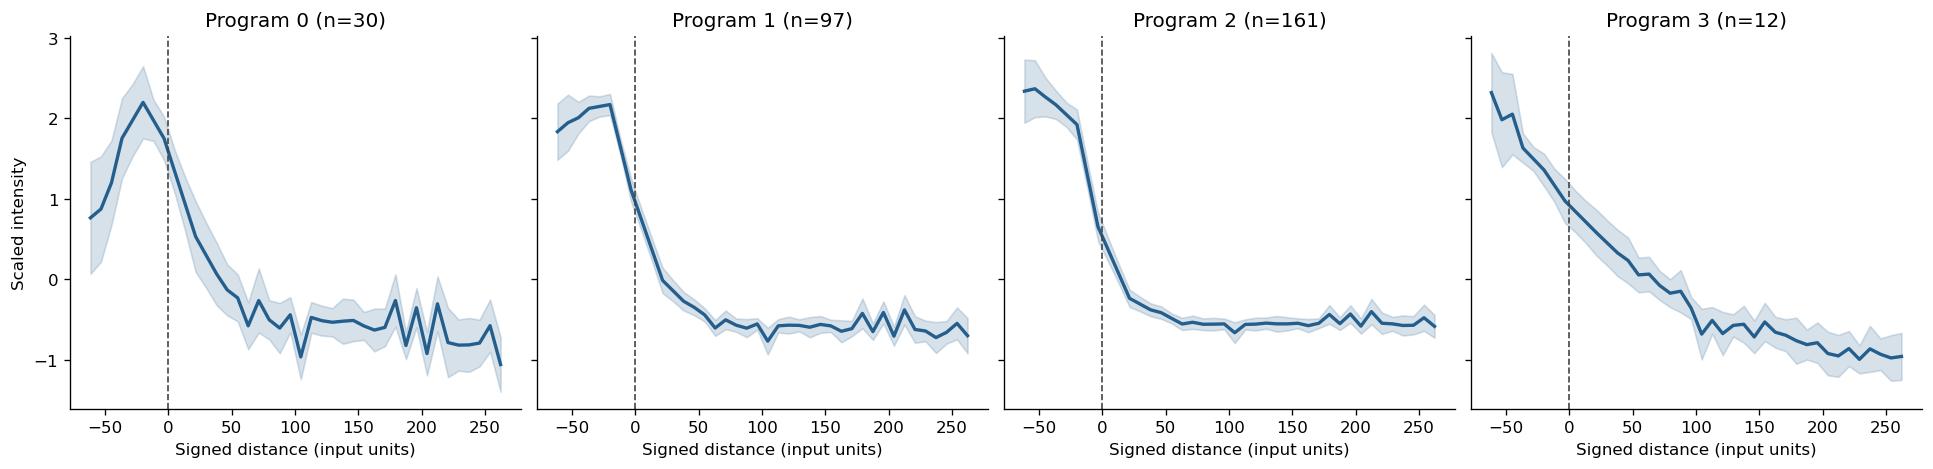

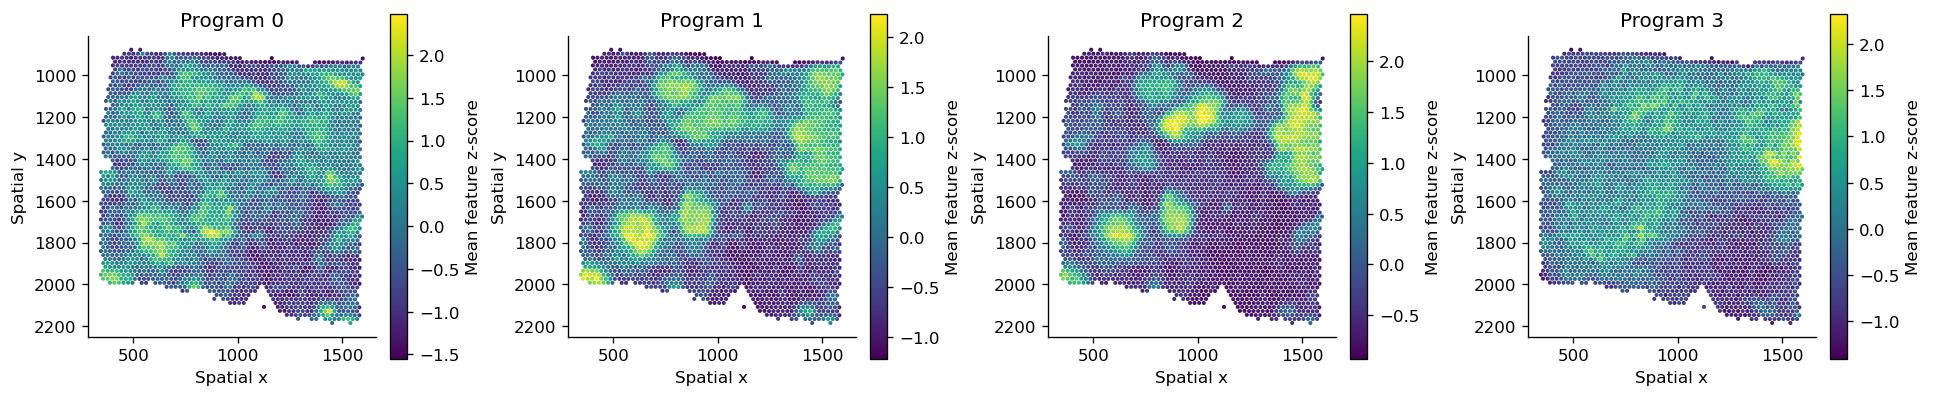

In [11]:
assert profile_mat.shape[1] == 40
print("Profile matrix:", profile_mat.shape)
display(meta_df.groupby("cluster").size().rename("Features").to_frame())
meta_df.to_csv(OUT / "program_assignments.csv", index=False)
pd.DataFrame(module_scores, index=adata.obs_names).rename_axis("obs_id").to_csv(OUT / "program_scores.csv")
centers = 0.5 * (bins[:-1] + bins[1:])
clusters = sorted(meta_df["cluster"].unique())
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True, layout="constrained")
for ax, cluster in zip(axes, clusters):
    members = meta_df["cluster"].to_numpy() == cluster
    block = profile_mat[members]
    mean, sd = block.mean(axis=0), block.std(axis=0)
    ax.plot(centers, mean, color="#245E8D", linewidth=2)
    ax.fill_between(centers, mean - sd, mean + sd, color="#245E8D", alpha=0.18)
    ax.axvline(0, color="#444444", linestyle="--", linewidth=1)
    ax.set(title=f"Program {cluster} (n={members.sum()})", xlabel="Signed distance (input units)")
axes[0].set_ylabel("Scaled intensity")
fig.savefig(OUT / "program_profiles.png", bbox_inches="tight")
fig.savefig(OUT / "program_profiles.pdf", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), layout="constrained")
for ax, cluster in zip(axes, clusters):
    picture = ax.scatter(xy[:, 0], xy[:, 1], c=module_scores[int(cluster)], s=6, linewidths=0)
    ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set(title=f"Program {cluster}", xlabel="Spatial x", ylabel="Spatial y")
    fig.colorbar(picture, ax=ax, shrink=0.65, label="Mean feature z-score")
fig.savefig(OUT / "program_maps.png", bbox_inches="tight")
fig.savefig(OUT / "program_maps.pdf", bbox_inches="tight")
plt.show()

## One representative feature per program

Within each inferred program, remove lambda values above that program's 90th percentile and choose the feature with highest R², breaking ties by enrichment. This follows the original representative-selection step; representatives are not a global top-four list.

The lower panels use absolute distance, 30 quantile bins and mean ± SEM of min–max normalized intensities. Repeated distance values can reduce the number of distinct bins. Lambda and R² are fitted to raw intensities after the original log1p shift. The dashed display curve keeps that fitted slope and adjusts the intercept for normalized intensities, as in the original plotting code. It is not a new fit to the binned means.

In [12]:
import numpy as np
import pandas as pd
lambda_col = 'lambda' if 'lambda' in meta_df.columns else 'lam'
df_rep = meta_df.copy()
df_rep = df_rep.replace([np.inf, -np.inf], np.nan)
required_cols = ['cluster', 'mz', 'j', 'r2_logI']
missing = [c for c in required_cols if c not in df_rep.columns]
if missing:
    raise KeyError(f'Missing required columns in meta_df: {missing}')
rank_cols = ['r2_logI']
ascending = [False]
if 'boundary_enrichment_ratio' in df_rep.columns:
    rank_cols.append('boundary_enrichment_ratio')
    ascending.append(False)
if lambda_col in df_rep.columns:
    df_rep[lambda_col] = pd.to_numeric(df_rep[lambda_col], errors='coerce')
df_rep = df_rep.dropna(subset=['cluster', 'mz', 'j', 'r2_logI'])
rep_rows = []
for c in sorted(df_rep['cluster'].unique()):
    sub = df_rep[df_rep['cluster'] == c].copy()
    if sub.empty:
        continue
    if lambda_col in sub.columns:
        lam_cut = np.nanpercentile(sub[lambda_col], 90)
        sub2 = sub[sub[lambda_col] <= lam_cut].copy()
        if len(sub2) >= 1:
            sub = sub2
    sub = sub.sort_values(rank_cols, ascending=ascending)
    rep_rows.append(sub.iloc[0])
df_cluster_rep = pd.DataFrame(rep_rows).reset_index(drop=True)
display_cols = ['cluster', 'mz', 'j', 'r2_logI']
for col in ['boundary_enrichment_ratio', lambda_col, 'anisotropy_cv8']:
    if col in df_cluster_rep.columns:
        display_cols.append(col)
display(df_cluster_rep[display_cols])
df_cluster_rep.to_csv(OUT / "program_representatives.csv", index=False)

,cluster,mz,j,r2_logI,boundary_enrichment_ratio,lambda,anisotropy_cv8
0,0.0,817.534520,320.0,0.270282,2.411772,226.598438,0.423022
1,1.0,818.540767,134.0,0.269265,2.569555,195.740959,0.749549
2,2.0,887.561462,75.0,0.268716,3.657773,173.717959,0.928248
3,3.0,328.057840,438.0,0.216272,2.647179,309.712223,0.407631


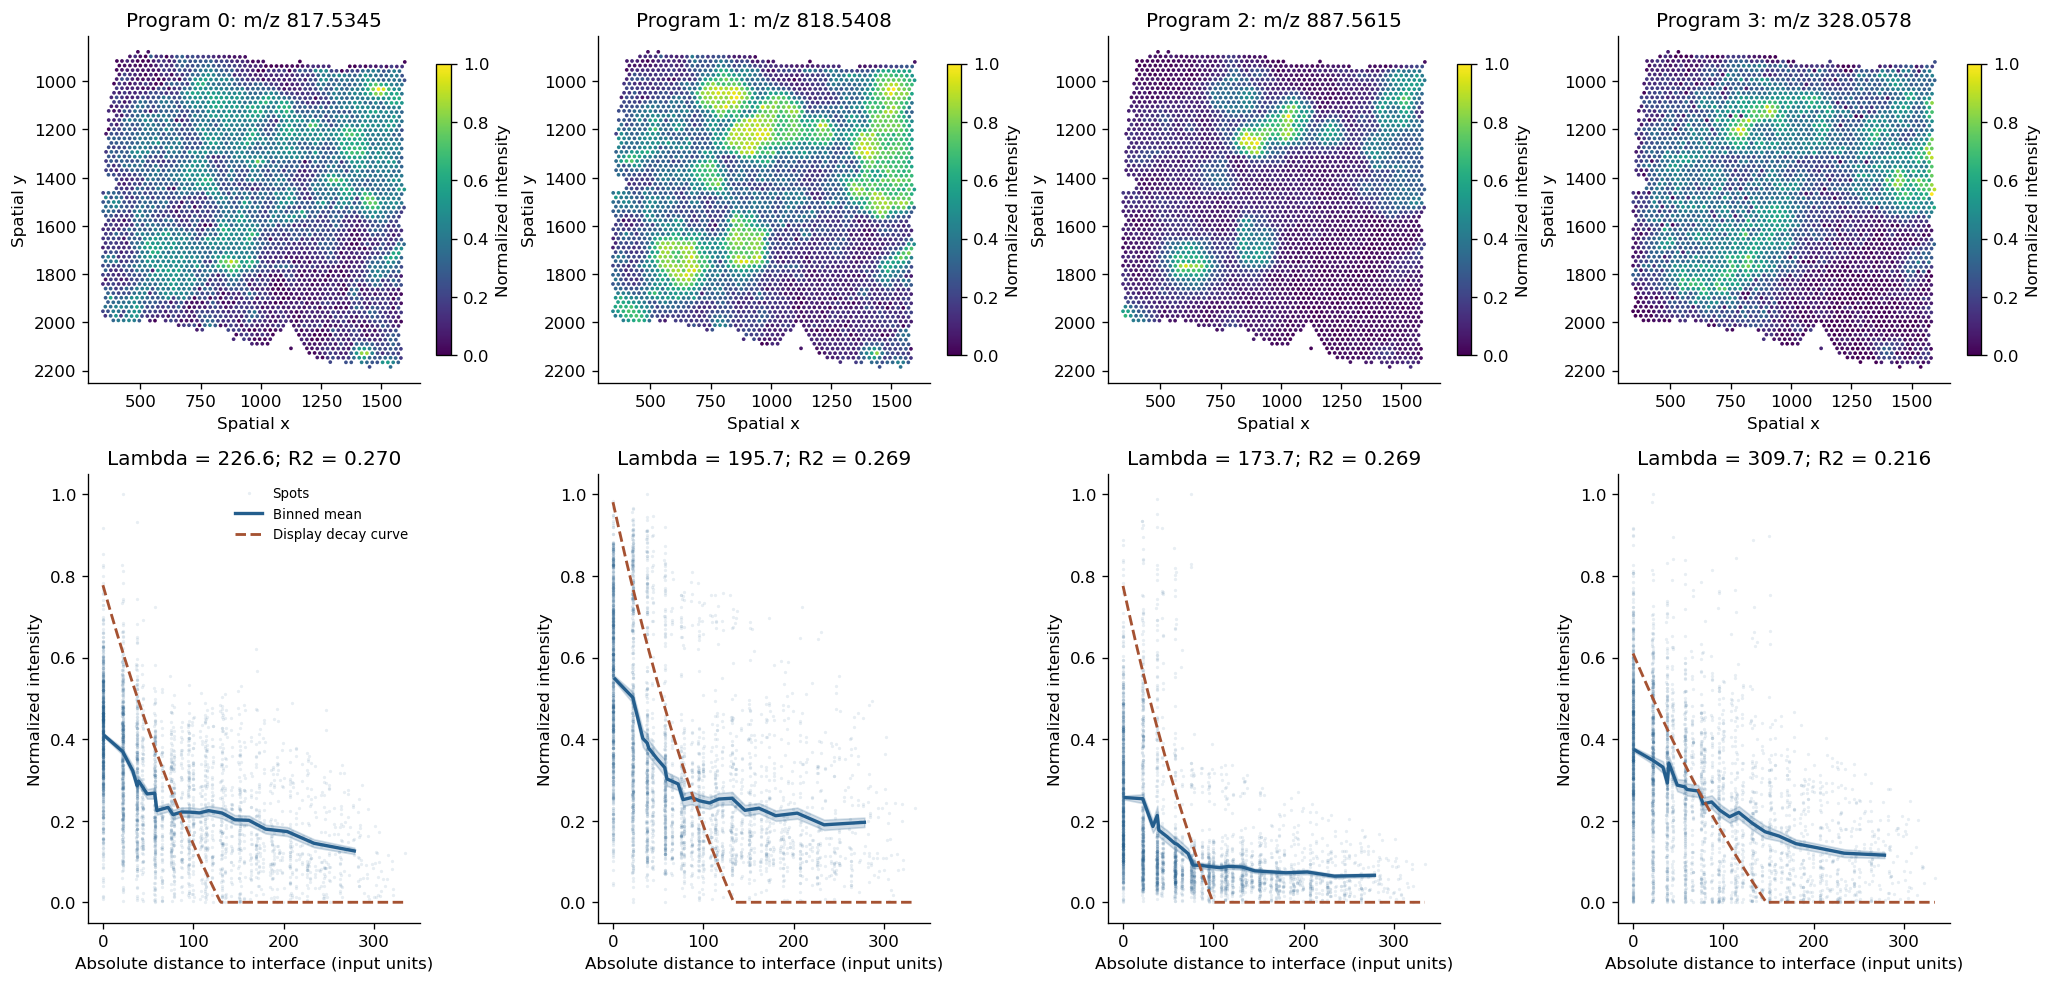

In [13]:
# Each column shows the representative chosen within one inferred program.
# Lambda and R2 come from the raw-intensity fit. The dashed curve follows
# the original normalized-display convention: fixed slope, adjusted intercept.
fig, axes = plt.subplots(2, 4, figsize=(17, 8.3), layout="constrained")
profile_rows = []
for column, (_, row) in enumerate(df_cluster_rep.iterrows()):
    intensity = column_get(msi, int(row["j"])).astype(float)
    distance = np.abs(d_signed)
    valid = np.isfinite(distance) & np.isfinite(intensity)
    dd, raw = distance[valid], intensity[valid]
    normalized = (raw - np.nanmin(raw)) / (np.nanmax(raw) - np.nanmin(raw) + 1e-8)
    color_values = (intensity - np.nanmin(intensity)) / (np.nanmax(intensity) - np.nanmin(intensity) + 1e-8)
    ax = axes[0, column]
    picture = ax.scatter(xy[:, 0], xy[:, 1], c=color_values, s=5, vmin=0, vmax=1, linewidths=0)
    ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set(title=f"Program {int(row['cluster'])}: m/z {float(row['mz']):.4f}", xlabel="Spatial x", ylabel="Spatial y")
    fig.colorbar(picture, ax=ax, shrink=0.65, label="Normalized intensity")

    edges = np.unique(np.quantile(dd, np.linspace(0, 1, 31)))
    ids = np.digitize(dd, edges[1:-1], right=True)
    xb, mean, sem = [], [], []
    for b in range(len(edges) - 1):
        use = ids == b
        if use.any():
            xb.append(np.nanmean(dd[use]))
            mean.append(np.nanmean(normalized[use]))
            sem.append(np.nanstd(normalized[use]) / np.sqrt(use.sum()))
            profile_rows.append({"cluster": int(row["cluster"]), "mz": str(row["mz"]),
                                 "bin": b, "distance_mean": xb[-1], "mean_normalized_intensity": mean[-1],
                                 "sem": sem[-1], "n_spots": int(use.sum())})
    xb, mean, sem = np.asarray(xb), np.asarray(mean), np.asarray(sem)
    shift = np.nanmin(normalized)
    transformed = np.log1p(np.clip(normalized - shift, 0, None))
    display_intercept = np.nanmean(transformed - row["slope"] * dd)
    grid = np.linspace(0, dd.max(), 300)
    fitted = np.clip(np.expm1(display_intercept + row["slope"] * grid) + shift, 0, 1)
    ax = axes[1, column]
    ax.scatter(dd, normalized, s=4, alpha=0.10, linewidths=0, color="#245E8D", label="Spots")
    ax.plot(xb, mean, linewidth=2, color="#245E8D", label="Binned mean")
    ax.fill_between(xb, mean - sem, mean + sem, color="#245E8D", alpha=0.2)
    ax.plot(grid, fitted, linestyle="--", linewidth=1.7, color="#A55232", label="Display decay curve")
    ax.set(title=f"Lambda = {row['lambda']:.1f}; R2 = {row['r2_logI']:.3f}",
           xlabel="Absolute distance to interface (input units)", ylabel="Normalized intensity")
    if column == 0:
        ax.legend(frameon=False, fontsize=8)
fig.savefig(OUT / "representative_metabolites.png", bbox_inches="tight")
fig.savefig(OUT / "representative_metabolites.pdf", bbox_inches="tight")
plt.show()
pd.DataFrame(profile_rows).to_csv(OUT / "representative_distance_profiles.csv", index=False)

## Export numerical results

Save the input checksum, protocol, software versions, training history, complete lambda ranking, program assignments, representatives and spatial outputs. Figures are exported as PNG and PDF.

In [14]:
source_dir = ROOT / "vendor/SIGMA/src/sigma_spatial"
source_hashes = {name: sha256(source_dir / name) for name in [
    "__init__.py", "model.py", "graph.py", "pipeline.py", "preprocessing.py",
    "boundary.py", "lambda_profile.py", "programs.py"]}
summary = {
    "implementation": IMPLEMENTATION, "protocol": PROTOCOL, "input_sha256": input_hash,
    "spots": int(adata.n_obs), "msi_features": int(msi.shape[1]),
    "core": CORE, "seed": SEED, "device": "cpu", "threads": 1,
    "initial_loss": float(loss_history[0]), "final_loss": float(loss_history[-1]),
    "inside_spots": int(inside.sum()), "boundary_spots": int(boundary.sum()),
    "retained_lambda_features": int(len(ranking)), "clustered_features": int(len(meta_df)),
    "program_sizes": {str(k): int(v) for k, v in meta_df.groupby("cluster").size().items()},
    "representatives": df_cluster_rep[["cluster", "mz", "j", "lambda", "r2_logI", "boundary_enrichment_ratio"]].to_dict("records"),
    "training_seconds": training_seconds, "versions": versions,
    "library_compatibility_version": "0.3.1+bc515.original", "vendor_source_sha256": source_hashes,
    "reference_scope": "Original BC-515 protocol rerun; saved historical outputs are reported separately."
}
(OUT / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
np.savez_compressed(OUT / "outputs.npz", obs_names=adata.obs_names.to_numpy(dtype=str),
                    xy=xy, embedding=embedding, gaussian=gaussian, residual=residual,
                    corrected=gaussian + residual, gaussian_anchor=gaussian_anchor,
                    probability=probability, p_raw=p_raw, inside=inside, boundary=boundary,
                    d_signed=d_signed, loss_history=np.asarray(loss_history),
                    profile_matrix=profile_mat, program_feature_index=meta_df["j"].to_numpy(int),
                    program_labels=meta_df["cluster"].to_numpy(int),
                    module_scores=np.column_stack([module_scores[c] for c in sorted(module_scores)]),
                    input_sha256=np.array(input_hash), protocol=np.array(PROTOCOL))
pd.DataFrame({"obs_id": adata.obs_names, "score": probability, "inside": inside,
              "boundary": boundary, "d_signed": d_signed}).to_csv(OUT / "spatial_results.csv", index=False)
pd.DataFrame({"epoch": np.arange(1, len(loss_history) + 1), "loss": loss_history}).to_csv(OUT / "training_loss.csv", index=False)
print("Saved numerical outputs, ranking, programs and figures to:", OUT.relative_to(ROOT))

Saved numerical outputs, ranking, programs and figures to: results/sigma_library


## Comparison with the original saved run

These historical values were read from the original notebook. They are not used for fitting, selection or tuning. A fresh execution may differ numerically because of the runtime; the comparison makes those differences visible.

In [15]:
# Historical numbers are reference observations, not targets used during training.
historical = {"Inside spots": 752, "Boundary spots": 834, "Retained decay features": 310,
              "Initial loss (rounded)": 0.4260, "Final loss (rounded)": 0.1564}
current = {"Inside spots": int(inside.sum()), "Boundary spots": int(boundary.sum()),
           "Retained decay features": len(ranking), "Initial loss (rounded)": round(loss_history[0], 4),
           "Final loss (rounded)": round(loss_history[-1], 4)}
comparison = pd.DataFrame({"Original saved notebook": historical, "This execution": current})
display(comparison)
comparison.to_csv(OUT / "historical_comparison.csv", index_label="measure")
print("Historical numbers are descriptive. CPU, library versions and numerical rounding can change a new training run.")

,Original saved notebook,This execution
Inside spots,752.0000,751.0000
Boundary spots,834.0000,838.0000
Retained decay features,310.0000,312.0000
Initial loss (rounded),0.4260,0.4253
Final loss (rounded),0.1564,0.1556


Historical numbers are descriptive. CPU, library versions and numerical rounding can change a new training run.


## Source and license

The original algorithm comes from `HBC_515/HBC_515_SIGMA.ipynb`. The SIGMA source is distributed under its included MIT license. The bundled source is **SIGMA 0.3.1+bc515.original**, a documented compatibility revision of 0.3.1. It restores the original RNA-first head initialization, diffusion arithmetic, class-weight dtype, NumPy sigmoid, raw-intensity profile aggregation and module scoring. See `vendor/SIGMA/ORIGINAL_COMPATIBILITY.md`. It is not an unchanged PyPI release.